In [4]:
# https://www.archrproject.com/bookdown/chromvar-deviatons-enrichment-with-archr.html
# Note: this requires the previous execution of (...)/add_motif_annotation/archR_add_motif_annotation.R
here::i_am("atac/archR/chromvar/cells/run_chromvar_from_archR.R")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressMessages(library(GenomicRanges))
suppressMessages(library(ArchR))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code



In [35]:
# START TEST ##
test=TRUE
if(test==TRUE){
args <- list()
args$archr_directory <- file.path(io$basedir,"processed/atac/archR")
args$motif_annotation <- "CISBP"
args$metadata <- file.path(io$basedir,"results/atac/archR/qc/sample_metadata_after_qc.txt.gz")
args$threads <- 1
args$force <- FALSE
args$outdir <- file.path(io$basedir,"results/atac/archR/chromvar")
}
## END TEST ##

#####################
## Load metadata ##
#####################

sample_metadata <- fread(args$metadata) %>%
  .[pass_atacQC==TRUE & doublet_call==FALSE]

########################
## Load ArchR Project ##
########################

# source(here::here("atac/archR/load_archR_project.R"))

setwd(args$archr_directory)

addArchRGenome("mm10")
addArchRThreads(threads = args$threads)

ArchRProject <- loadArchRProject(args$archr_directory)[sample_metadata$cell]



Setting default genome to Mm10.

Setting default number of Parallel threads to 1.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\__

In [45]:
#######################################
## Sanity checks on the ArchR object ##
#######################################

# Load motif annotations over peaks
tmp <- file.path(args$archr_directory,"Annotations/peakAnnotation.rds")
if (file.exists(tmp)) {
	ArchRProject@peakAnnotation <- readRDS(tmp)
}
stopifnot(TRUE %in% grepl(args$motif_annotation, names(ArchRProject@peakAnnotation), ignore.case = TRUE))


In [ ]:
args$motif_annotation

In [55]:
test = readRDS("/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/atac/archR/chromvar/cells/chromVAR_deviations_Motif_JASPAR2020_archr.rds")

In [151]:
test = readRDS("/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/atac/archR/chromvar/cells/chromVAR_deviations_CISBP_archr.rds")

In [152]:
test

class: SummarizedExperiment 
dim: 884 1999 
metadata(0):
assays(2): deviations z
rownames(884): Tcfap2a_1 Tcfap2b_2 ... Smad5_883 Smad9_884
rowData names(2): idx name
colnames(1999): 2_Eo_DEG_G9_day5_dTAG#GCGCCTTGTTACGCGG-1
  2_Eo_DEG_G9_day5_dTAG#ATGGTGCGTGCATTTC-1 ...
  2_Eo_DEG_G9_day5_VC#GACCTTTGTTGCGGAT-1
  2_Eo_DEG_G9_day5_VC#CGCTCCATCATCCTGC-1
colData names(38): BlacklistRatio nDiFrags ... ReadsInPeaks FRIP

In [153]:
test2 = test@assays@data$z

In [157]:
test3 = test2[grepl(paste(c('GATA1', 'GATA2', 'LYL1', 'FLI1','ERG','PU', 'CEBPB'), collapse='|'), rownames(test2), ignore.case=TRUE),]

In [158]:
test4 = as.data.table(as.matrix(t(test3)), keep.rownames=T) 
test5 = test4%>% gather('TF', 'Z', -rn)
head(test4)

rn,Cebpb_130,Fli1_277,Erg_287,Gata2_383,Gata1_387,Lyl1_783
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2_Eo_DEG_G9_day5_dTAG#GCGCCTTGTTACGCGG-1,-0.55182132,-2.410455,-2.417023,-3.796607,-4.100198,3.559930
2_Eo_DEG_G9_day5_dTAG#ATGGTGCGTGCATTTC-1,-0.90600457,-3.727004,-3.803782,-2.658505,-3.288138,2.534055
2_Eo_DEG_G9_day5_dTAG#CCGGTTAAGCGAAGTA-1,-2.24132572,1.727062,1.840862,3.694202,3.856069,1.313550
2_Eo_DEG_G9_day5_dTAG#ATTGGCTAGGAGCACG-1,-2.19527248,-9.761559,-10.008682,2.722108,2.492080,3.919478
2_Eo_DEG_G9_day5_dTAG#AGACAATAGACTAAGG-1,0.51759080,-3.745113,-3.897862,-5.383595,-5.999167,2.292478
2_Eo_DEG_G9_day5_dTAG#GGAAGCTAGCTCCTTA-1,-0.02085435,-8.152686,-7.989476,-3.096495,-2.879502,-0.155665


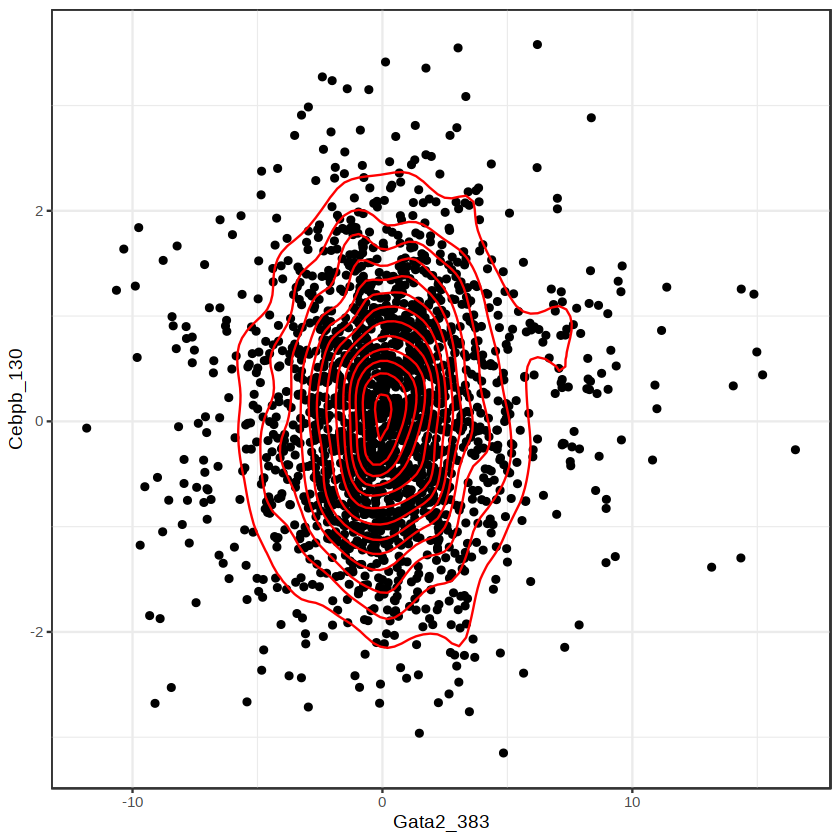

In [165]:
#	 GATA1_577
ggplot(test4, aes(Gata2_383, Cebpb_130)) + geom_point() + geom_density2d(col='red') + theme_bw() + theme(panel.background=element_rect(color='black'))

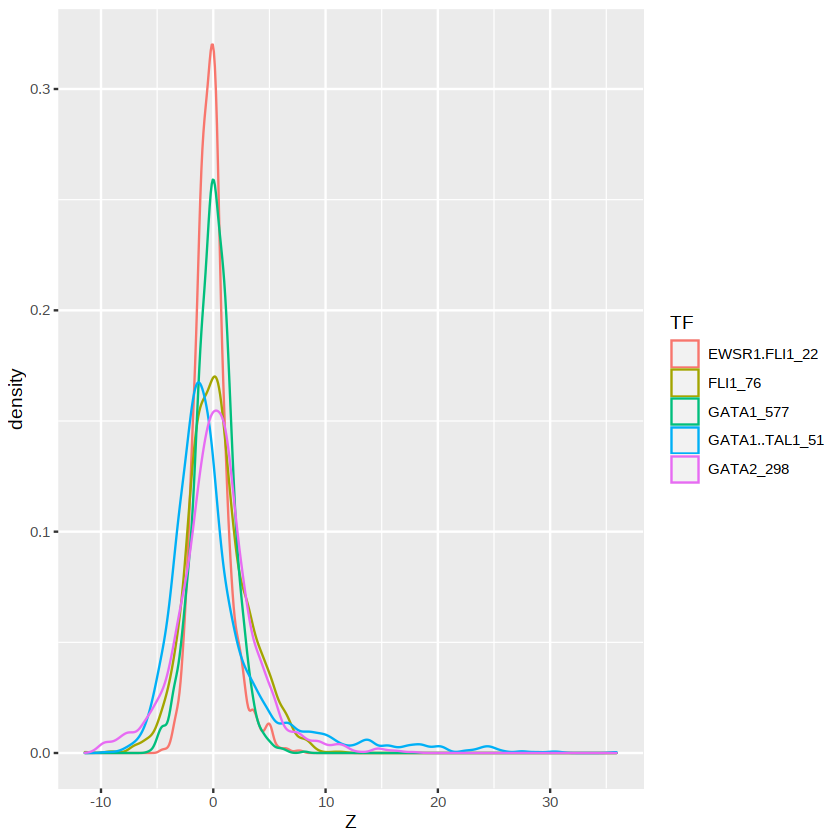

In [100]:
ggplot(test5, aes(Z, col=TF)) + geom_density()

In [69]:
ggplot(test3) + geom_density()

ERROR: Error: `data` must be a data frame, or other object coercible by `fortify()`, not a numeric vector.


In [42]:
matrix_name <- paste0("DeviationMatrix_",args$motif_annotation)

# Rename motif annotation to correct name
args$motif_annotation = names(ArchRProject@peakAnnotation)[grepl(args$motif_annotation, names(ArchRProject@peakAnnotation), ignore.case = TRUE)]

ArchRProject <- addDeviationsMatrix(
	  ArchRProject, 
	  matrixName = matrix_name,
	  peakAnnotation = args$motif_annotation,
	  out = c("z", "deviations"),
	  binarize = FALSE
	)

Identifying Background Peaks!

ArchR logging to : ArchRLogs/ArchR-addDeviationsMatrix-4e641445dbe4-Date-2022-05-31_Time-15-21-47.log
If there is an issue, please report to github with logFile!



NULL


ERROR: Error in getPeakAnnotation(ArchRProj, peakAnnotation): Name is not in peakAnnotation!


In [167]:
test = data.frame(a = c('a','b'))

In [176]:
test$a = factor(test$a, levels=c('a','b','c', 'd'))

In [177]:
test$a

[1] a b
Levels: a b c d

In [150]:
 rhdf5::h5disableFileLocking()

In [97]:
 file.path(args$outdir,sprintf("chromVAR_deviations_%s_archr.rds",args$motif_annotation))

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/atac/archR/chromvar/chromVAR_deviations_CISBP_archr.rds"